<a href="https://colab.research.google.com/github/marcosscofano/puc-rio_mvp_machine_learning/blob/main/Machine_Learning_%26_Analytics_(Marcos_Scofano_4052025000585).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Template — MVP: *Machine Learning & Analytics*
**Autor:** Marcos Pasquale Vieira Scofano

**Data:** 14/09/2025

**Matrícula:** 4052025000585

**Dataset:** [Medical Appointment No Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments)



## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)


# 1. Escopo, objetivo e definição do problema

O conjunto de dados de faltas (*no show*) em consultas médicas (*medical appointments*) consiste em marcações realizadas no SUS, ou seja, no Brasil (estado do ES) no mês/ano de Maio/2016.

Este trabalho tem como escopo o problema de absenteísmo em consultas médicas utilizando o dataset “Medical Appointment No Shows”, que reúne registros de agendamentos realizados no Brasil com variáveis demográficas e clínicas, além do indicador de comparecimento à consulta

⚠️ **Obs.:** o dataset utilizado é o mesmo utilizado na _sprint_ anterior (Análise de Dados e Boas Práticas). A intenção é dar continuidade ao trabalho realizado.

As etapas de análise exploratória de dados e de pré-processamento foram integralmente conduzidas na _sprint_ anterior, resultando em um conjunto de dados limpo, documentado e pronto para modelagem supervisionada no contexto do problema de no-show em consultas médicas. Ainda assim, essas fases poderão ser revisitadas de forma pontual nesta _sprint_ sempre que necessário, por exemplo, para ajustar codificações, tratar desbalanceamento, refinar features derivadas (como antecedência do agendamento) ou mitigar vazamentos de informação detectados durante a validação dos modelos. Dessa forma, preserva-se a reprodutibilidade do trabalho anterior, ao mesmo tempo em que se garante flexibilidade para alinhá-lo às exigências e achados do processo atual de modelagem.

O objetivo do trabalho é desenvolver um modelo de aprendizado supervisionado para o problema de classificação “show vs. no-show”, capaz de estimar se um paciente irá ou não faltar à consulta a partir dos atributos do dataset “Medical Appointment No Shows”. A partir daqui, o modelo será ajustado para operar com cortes de decisão e métricas adequadas ao caso de uso, ressaltando que a análise exploratória não identificou uma variável ou um conjunto discreto de variáveis suficientemente “fortes” para determinar a falta. Portanto, o objetivo é explorar um conjunto amplo de variáveis que excede a capacidade humana de análise manual, capturando interações e padrões sutis que só emergem via modelagem estatística e de machine learning.

## Tipo de Problema

Este é um problema de **classificação binária supervisionada**. O objetivo é prever se um paciente vai faltar ou não à consulta médica, com base em informações prévias como idade, gênero, bairro, presença de doenças crônicas, recebimento de SMS, entre outros. O atributo alvo (target) é a variável **No-show**, que originalmente assume dois valores possíveis:

  - `No` → compareceu à consulta;
  - `Yes` → faltou à consulta


## 2. Reprodutibilidade e ambiente
Para garantir reprodutibilidade, o fluxo foi organizado em etapas modulares com pipelines do scikit-learn, encapsulando todo o pré-processamento e a modelagem em uma sequência única. Com isso, o mesmo processo pode ser reaplicado em novos dados sem ajustes manuais, reduzindo erros e assegurando consistência entre execuções.

O desenvolvimento ocorreu no Google Colab, que oferece suporte integrado às bibliotecas necessárias e facilita o versionamento do notebook via GitHub, além de acelerar experimentos. As principais dependências foram:

*   pandas e numpy: manipulação e análise de dados;
*   matplotlib e seaborn: visualização exploratória e comunicável;
*   scikit-learn: transformação, modelagem e avaliação dentro de pipelines;
*   tabulate: visualização aprimorada de tabelas;
*   kagglehub: biblioteca para carga automática de datasets do Kaggle.

Esse arranjo permite repetir o treinamento com configurações idênticas, documentar cada transformação e manter um caminho claro do dado bruto até as previsões, o que é essencial para manutenção e auditoria do projeto.

In [1]:
# === Setup básico e reprodutibilidade ===
import random, time, sys, math, warnings
import numpy as np
import pandas as pd
from tabulate import tabulate
import time
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, r2_score, make_scorer, classification_report, ConfusionMatrixDisplay)
from sklearn.svm import SVC

# Ignorar warnings para manter a saída sem mensagens indesejadas
warnings.filterwarnings('ignore')

SEED = 23
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

Python: 3.12.11
Seed global: 23


### 2.2 Funções python (opcional)
Defina, se necessário, funções em Python para reutilizar seu código e torná-lo mais organizado. Essa é uma boa prática de programação que facilita a leitura, manutenção e evolução do seu projeto.

In [2]:
def evaluate_classification(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, proba[:,1]) if (proba is not None and proba.shape[1]==2) else np.nan
    return {"accuracy": acc, "f1_weighted": f1w, "roc_auc": auc}

## 3. Dados: carga, entendimento e qualidade

### 3.1 Descrição do Dataset

O dataset de consultas médicas do SUS foi encontrado no site do Kaggle, sendo este uma plataforma online amplamente conhecida e voltada para ciência de dados e aprendizado de máquina. O Kaggle, entre outras funcionalidades, oferece um grande repositório de conjuntos de dados prontos para análise e modelagem.

| Variável | Tipo | Selecionar? | Justificativa | Descrição |
| :-- | :-- | :-- | :-- | :-- |
| PatientId | Numérico | ❌ Não | Identificador único do paciente. Não possui valor preditivo. | Identificador do paciente (pode se repetir para pacientes diferentes) |
| AppointmentID | Numérico | ❌ Não | Apenas identificador da consulta. Sem utilidade para análise ou modelagem. | Identificador único da consulta |
| Gender | Categórico | ✅ Sim | Pode influenciar o comportamento de comparecimento. | Sexo do paciente (`F` ou `M`) |
| ScheduledDay | Data/hora | ✅ Sim | Permite calcular o tempo de espera (diferença entre agendamento e consulta). | Data e hora em que a consulta foi marcada |
| AppointmentDay | Data/hora | ✅ Sim | Usada junto a `ScheduledDay` para calcular variáveis derivadas. | Data e hora da consulta propriamente dita |
| Age | Numérico | ✅ Sim | A idade pode influenciar o comparecimento ou ausência. | Idade do paciente |
| Neighbourhood | Categórico | ✅ Sim | Pode representar fatores socioeconômicos ou acesso à saúde. | Bairro onde o paciente mora |
| Scholarship | Binário | ✅ Sim | Indicador social relevante que pode afetar o comportamento de saúde. | 1 se o paciente participa de programa social (Bolsa Família), 0 caso contrário |
| Hipertension | Binário | ✅ Sim | Comorbidade potencialmente associada a maior comprometimento com consultas. | 1 se o paciente tem hipertensão, 0 caso contrário |
| Diabetes | Binário | ✅ Sim | Relevante como condição crônica, pode influenciar o engajamento com o tratamento. | 1 se o paciente tem diabetes, 0 caso contrário |
| Alcoholism | Binário | ✅ Sim | Pode estar associado a comportamentos de risco e faltas. | 1 se o paciente é alcoólatra, 0 caso contrário |
| Handcap | Binário | ✅ Sim | Indica limitações físicas que podem influenciar o comparecimento. | 0 (sem deficiência) a 4 (níveis de deficiência) |
| SMS_received | Binário | ✅ Sim | Relacionado diretamente à comunicação e possível engajamento do paciente. | 1 se o paciente recebeu SMS de lembrete, 0 caso contrário |
| No-show | Categórico | ✅ Sim (alvo 🎯) | Variável-alvo da análise preditiva (target). | "Yes" se o paciente faltou à consulta, "No" se compareceu |






### 3.2 Carga do Dataset

In [3]:
#CARGA do DATASET
df = None
# Buscando dados diretamente do repositório do GitHub criado para o MVP
try:
  print("Buscando arquivo csv do GitHub 🔍...")
  # Fazendo a leitura para um dataframe Pandas
  df = pd.read_csv("https://raw.githubusercontent.com/marcosscofano/puc-rio_mvp_analise_dados/refs/heads/main/KaggleV2-May-2016.csv")
  print("Arquivo carregado 👍🏻!")
except Exception as ex:
  #Em caso de alguma impossibilidade de carga via GitHub, o algoritmo tenta carregar o dataset direto do repositório do Kaggle
  print("⚠️ Não foi possível baixar o arquivo do repositório. Motivo:",ex)
  print("Tentando diretamente do repositório do Kaggle 🔍...")
  try:
    path = kagglehub.dataset_download("joniarroba/noshowappointments")
    print("Caminho para o arquivo 📂:", path)
    # Montando o caminho completo até o arquivo CSV
    csv_path = os.path.join(path, "KaggleV2-May-2016.csv")
    # Fazendo a leitura para um dataframe Pandas
    df = pd.read_csv(csv_path)
    print("Arquivo carregado 👍🏻!")
  except Exception as ex:
    print("⚠️ Não foi possível baixar o arquivo do repositório. Motivo:",ex)

#Salvando o dataframe original
dfOriginal = df.copy()

if not df.empty:
  print("\nPrimeiras 10 linhas 🔍:")
  print(tabulate(df.head(10), headers='keys', tablefmt='plain'))


Buscando arquivo csv do GitHub 🔍...
Arquivo carregado 👍🏻!

Primeiras 10 linhas 🔍:
      PatientId    AppointmentID  Gender    ScheduledDay          AppointmentDay          Age  Neighbourhood        Scholarship    Hipertension    Diabetes    Alcoholism    Handcap    SMS_received  No-show
 0  2.98725e+13          5642903  F         2016-04-29T18:38:08Z  2016-04-29T00:00:00Z     62  JARDIM DA PENHA                0               1           0             0          0               0  No
 1  5.58998e+14          5642503  M         2016-04-29T16:08:27Z  2016-04-29T00:00:00Z     56  JARDIM DA PENHA                0               0           0             0          0               0  No
 2  4.26296e+12          5642549  F         2016-04-29T16:19:04Z  2016-04-29T00:00:00Z     62  MATA DA PRAIA                  0               0           0             0          0               0  No
 3  8.67951e+11          5642828  F         2016-04-29T17:29:31Z  2016-04-29T00:00:00Z      8  PONTAL DE CAMB

### 3.3 Verificações de Qualidade do Dataset

Nessa seção foram realizadas apenas algumas validações do dataset para exemplificação, pois esta tarefa já foi amplamente realizada na *sprint* anterior (https://github.com/marcosscofano/puc-rio_mvp_analise_dados.git).

In [4]:

# === Verificações iniciais ===
display(df.sample(5))
print("\nFormato:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
23738,3.353668e+12,5587623,F,2016-04-15T08:53:07Z,2016-05-10T00:00:00Z,51,SANTO ANTÔNIO,1,0,0,0,1,0,Yes
57770,1.143785e+12,5659955,F,2016-05-04T15:09:46Z,2016-05-04T00:00:00Z,19,NOVA PALESTINA,0,0,0,0,0,0,No
43854,5.859936e+13,5652427,F,2016-05-03T10:04:54Z,2016-05-20T00:00:00Z,54,CONSOLAÇÃO,0,0,0,0,0,0,Yes
45803,3.664357e+14,5614250,F,2016-04-25T10:16:19Z,2016-05-11T00:00:00Z,50,CENTRO,0,1,0,0,0,1,No
103633,5.449686e+12,5702865,F,2016-05-16T13:08:09Z,2016-06-06T00:00:00Z,9,ANDORINHAS,0,0,0,0,0,1,No



Formato: (110527, 14)

Tipos:
PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

Valores ausentes por coluna:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


### 3.4 Análise exploratória resumida (EDA)
A Análise Exploratória de Dados já foi realizada no trabalho da *sprint* anterior que pode ser encontrada na seguinte URL: https://github.com/marcosscofano/puc-rio_mvp_analise_dados.git

Entretanto reproduzirei aqui a distribuição total entre as classes da variável alvo, matriz de correlação e um resumo dos insights obtidos anteriormente.

#### 3.4.1 - Distribuição entre as classes da variável alvo

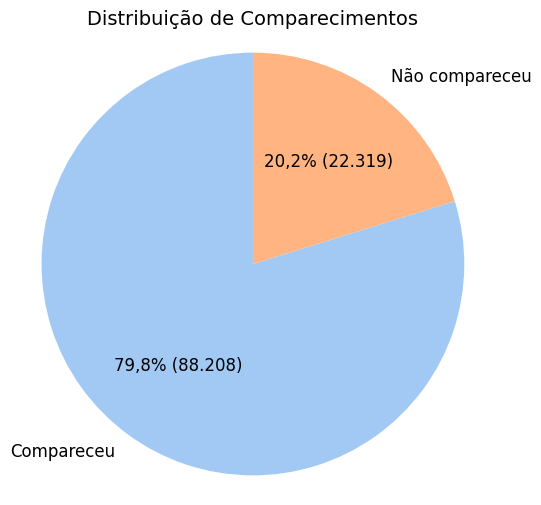

In [5]:
# Contagem dos valores da variável alvo
counts = df['No-show'].value_counts()
labels = ['Compareceu', 'Não compareceu']
colors = sns.color_palette("pastel")[0:2]
total = sum(counts.values)

# Função personalizada: percentual com vírgula + valor absoluto formatado
def format_label(pct, allvals):
    absolute = int(round(pct/100 * total))
    return f'{pct:.1f}'.replace('.', ',') + f'% ({absolute:,.0f})'.replace(',', '.')

# Gráfico de pizza
plt.figure(figsize=(6, 6))
plt.pie(counts.values,
        labels=labels,
        colors=colors,
        startangle=90,
        autopct=lambda pct: format_label(pct, counts.values),
        textprops={'fontsize': 12})
plt.title('Distribuição de Comparecimentos', fontsize=14)
plt.axis('equal')
plt.show()

#### 3.4.2 - Matriz de Correlação

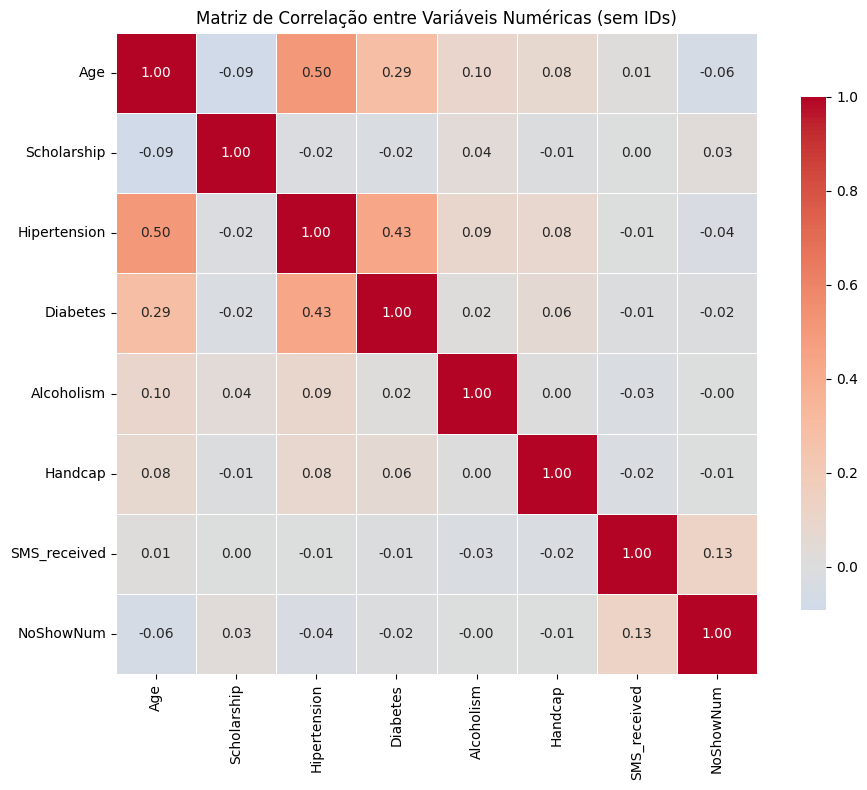

In [6]:
# Cria uma cópia do DataFrame para evitar alterar o original
df_corr = df.copy()

# Converte 'No-show' para valor numérico (1 = faltou, 0 = compareceu)
df_corr['NoShowNum'] = df_corr['No-show'].map({'Yes': 1, 'No': 0})

# Remove colunas de ID
df_corr = df_corr.drop(columns=['PatientId', 'AppointmentID'])

# Seleciona apenas colunas numéricas
df_numerico = df_corr.select_dtypes(include=['int64', 'float64'])

# Matriz de correlação
correlacao = df_numerico.corr()

# Gráfico de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlação entre Variáveis Numéricas (sem IDs)')
plt.tight_layout()
plt.show()

#####🧠 **Insights da Matriz de Correlação:**

✅ **Correlações com *No-Show* (variável-alvo)**:

| Variável         | Correlação | Interpretação                                                                                                                              |
| ---------------- | ---------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
| `DiasEspera`     | **0,19**   | Correlação **positiva fraca**: quanto maior o tempo de espera entre agendamento e consulta, **maior a chance de faltar**.                  |
| `SMS_received`   | **0,13**   | Correlação **positiva fraca**: quem recebeu SMS **faltou mais**, o que pode ser contraintuitivo (pode haver outros fatores explicativos).  |
| `Age`            | **-0,06**  | Correlação **negativa muito fraca**: pacientes mais velhos tendem a faltar um pouco menos.                                             |
| Demais variáveis | \~0,00     | Correlações **muito fracas ou inexistentes** com o `No-Show`, o que sugere que isoladamente essas variáveis não explicam bem a ausência. |

🧩 **Outras correlações notáveis**:

| Par de Variáveis              | Correlação | Interpretação                                                                       |
| ----------------------------- | ---------- | ----------------------------------------------------------------------------------- |
| `Hipertension` × `Age`        | **0.50**   | Correlação **moderada positiva**: pessoas mais velhas têm mais hipertensão.         |
| `Hipertension` × `Diabetes`   | **0.43**   | Também relacionado ao envelhecimento ou comorbidades.                               |
| `SMS_received` × `WaitDays` | **0.40**   | Pessoas que esperaram mais receberam mais SMS (talvez mais tempo = mais lembretes). |


#### 3.4.3 **Principais Conclusões da Análise Exploratória de Dados (EDA) 💡:**

**Distribuição de No-show:** cerca de 20 % de ausência, revelada em gráficos de barras, pizza e por gênero/faixa etária;

**Dias de espera:** tendência de aumento de faltas conforme cresce o intervalo entre agendamento e consulta;

**Fatores de risco:** pacientes com comorbidades (hipertensão, diabetes) ou sem SMS de lembrete apresentaram percentuais ligeiramente maiores de absenteísmo, mas correlações individuais foram fracas (< 0,2);

**Correlação:** matriz mostrou correlação maior entre idade e comorbidades, e pouca correlação linear direta com faltas.

De forma geral, não é possível atribuir a ausência dos pacientes a um único fator isolado. As faltas parecem decorrer de uma combinação de elementos operacionais (como forma de agendamento e envio de lembretes), características clínicas e aspectos socioeconômicos.


## 4. Definição do target, variáveis e divisão dos dados
Conforme informado na seção 3. A variável *target* é a "No-Show", conforme reprodução abaixo:

| Variável | Tipo | Selecionar? | Justificativa | Descrição |
| :-- | :-- | :-- | :-- | :-- |
| No-show | Categórico | ✅ Sim (alvo 🎯) | Variável-alvo da análise preditiva (target). | "Yes" se o paciente faltou à consulta, "No" se compareceu |

In [7]:
#Tipo de Problema
PROBLEM_TYPE = "classificacao"

# Defina features e target conforme o problema
target = "No-show"
features = [c for c in df.columns if c not in [target, "timestamp"]]

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))

# Divisão dos dados
X = df[features].copy()
y = df[target].copy()
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y if PROBLEM_TYPE=="classificacao" else None
    )
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

PROBLEM_TYPE: classificacao
Target: No-show
N features: 13
Treino: (88421, 13) | Teste: (22106, 13)


## 5. Tratamento de dados e **Pipeline** de pré-processamento

### 5.1 Tratamento de dados e Engenharia de Atributos

Os seguintes tratamentos foram desenvolvidos e adicionados ao piepeline:

-   **Correção da idade negativa:**  o objetivo é corrigir única linha que apresenta idade negativa. ⚠️ **Obs.:** o autor do *dataset* foi questionado e informou a idade negativa refere-se a bebês ainda em gestação. Por se tratar de um único caso, foi decidido realizar o tratamento;
-   **Transformação da variável de gênero:** o objetivo é criar uma coluna binária que represente os gêneros, sendo "0" para "M" (masculino) e "1" para "F" (femminino);
-   **Cálculo do Dia da Semana (*Weekday*):** o objetivo é criar uma coluna de dia da semana a partir da data da consulta. (de 1 - domingo até 7 - sábado);
-   **Remoção de Colunas Desnecessárias para o Modelo:** tem como objetivo excluir as colunas que não serão usadas para treinar e utilizar o futuro modelo de machine learning. São elas:

    - *AppointmentId* e *PacientId*: são colunas identificadoras de consulta e paciente. Não fazem sentido para o modelo;
    - *AppointmentDay* e *ScheduledDay*: variáveis de data/hora. A semântica desse tipo de dado está representada pelas colunas calculadas de dias de espera (diferença em dias entre *AppointmentDay* e *ScheduledDay*) e dia da semana (*WeekDay*) calculado a partir da data da consulta (*AppointmentDay*);
- **Tratamento da Coluna de Gênero (Gender):** o objetivo é transformar a variável categórica de gênero para numérico (0 - Masculino e 1 - Feminino)

In [8]:
#Tratamento da idade negativa
def clip_age(df):
    df = df.copy()
    if 'Age' in df.columns:
        df['Age'] = np.maximum(df['Age'], 0)
    return df
clip_age_pipe = FunctionTransformer(clip_age)

#Transformar gênero de F e M para 1 e 0
def map_gender(df):
    df = df.copy()
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'M': 0, 'F': 1}).astype('Int64')
    return df
gender_map_pipe = FunctionTransformer(map_gender)


#Adicionar variável de dia da semana do atendimento a partir da data da consulta
def add_weekday(df):
    df = df.copy()
    df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"], errors="coerce")
    w = df["AppointmentDay"].dt.weekday
    df["Weekday"] = ((w + 1) % 7) + 1
    return df

def weekday_feature_names(transformer, input_features=None):
    if input_features is None:
        return None
    return list(input_features) + ["Weekday"]

add_weekday_pipe = FunctionTransformer(
    add_weekday,
    feature_names_out=weekday_feature_names
)

#Adicionar a variável da quantidade de dias de espera a partir das datas em que a consulta foi marcada e data da consulta em si
def add_waitdays(df):
    df = df.copy()
    df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"], errors="coerce")
    df["ScheduledDay"]   = pd.to_datetime(df["ScheduledDay"], errors="coerce")
    # diferença em dias com datas normalizadas (ignora horas)
    diff_days = (df["AppointmentDay"].dt.normalize() - df["ScheduledDay"].dt.normalize()).dt.days
    df["WaitDays"] = diff_days.abs()  # módulo da diferença
    return df
add_waitdays_pipe= FunctionTransformer(add_waitdays)

#Retirada de variáveis consideradas desnecessárias para o modelo
drop_col_pipe = Pipeline(steps=[
      ("drop", FunctionTransformer(lambda X: X.drop(columns=['AppointmentID', 'PatientId', 'AppointmentDay', 'ScheduledDay','Neighbourhood'])))
  ])

#Normalização de variáveis numéricas
numeric_pipe = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

#One hot Envcoder utilizada na variável de bairro (Neighbourhood)
categorical_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

#Chamadas para as transformações no Pipeline
preprocess_group = ColumnTransformer(transformers=[
    ("num", numeric_pipe, ['Age','Handcap','Scholarship','Hipertension','Diabetes','Alcoholism','SMS_received','Gender','Weekday','WaitDays']),
    ("cat", categorical_pipe, ['Neighbourhood']),
    ("drop", drop_col_pipe,["AppointmentID", "PatientId", "AppointmentDay", "ScheduledDay","Neighbourhood"])
])

#Gerando o Pipeline
preprocess = Pipeline(steps=[
                            ('add_waitdays',add_waitdays_pipe),
                            ('gender_map',gender_map_pipe),
                            ('clip_age',clip_age_pipe),
                            ('add_weekday',add_weekday_pipe),
                            ("pre", preprocess_group)
                          ]
                   )


#Imprimindo o Pipeline
preprocess



Pipeline(steps=[('add_waitdays',
                 FunctionTransformer(func=<function add_waitdays at 0x7935ff1323e0>)),
                ('gender_map',
                 FunctionTransformer(func=<function map_gender at 0x7935ff132160>)),
                ('clip_age',
                 FunctionTransformer(func=<function clip_age at 0x7935ff1320c0>)),
                ('add_weekday',
                 FunctionTransformer(feature_names_out=<function weekday_feature_names at 0x7935ff1322a0>...
                                                   'Alcoholism', 'SMS_received',
                                                   'Gender', 'Weekday',
                                                   'WaitDays']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Neighbourhood']),
                                                 ('drop',
                                                  Pipeline(steps=[('drop',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7935ff132340>))]),
                                                  ['AppointmentID', 'PatientId',
                                                   'AppointmentDay',
                                                   'ScheduledDay',
                                                   'Neighbourhood'])]))])


## 6. Baseline e modelos candidatos

**Baseline:** o *baseline* utiliza um *DummyClassifier* com a estratégia “most_frequent”, que sempre prevê a classe mais comum observada no conjunto de treino, ignorando totalmente as variáveis preditoras. Como a variável alvo está desbalanceada em torno de 80% “Show” e 20% “No-Show”, a acurácia esperada desse baseline ficará próxima de 80%, pois o modelo classificará todas as amostras como “Show”. Isso é útil como piso de desempenho: qualquer modelo útil deve superar esse valor de referência em métricas apropriadas ao desbalanceamento, como F1 ponderado, recall da minoria e AUC, e não apenas acurácia.

**Modelos Candidatos**: serão avaliados diversos algoritmos de classificação apropriados ao problema, com o objetivo de superar o baseline em métricas relevantes ao desbalanceamento, como F1 ponderado, recall da classe minoritária e AUC, e não apenas acurácia.

⚠️ **Atenção:** o modelo SVM_RBF (*Support Vector Machine*) também foi avaliado, mas, apesar do sua acurácia ser a mais alta, notou-se que é a abordagem que requer o maior processamento computacional. O modelo foi retirado (veja a linha comentada no código abaixo) para que os avaliadores não precisem esperar pela demorada execução. Seguem os resultados alcançados do modelo:

| model | accuracy | f1_weighted | roc_auc | train_time_s |
| :-- | :-- | :-- | :-- | :-- |
| SVM_RBF | 0.798109 | 0.709143 | NaN | 506.456 |



In [9]:
# === Baselines ===
baseline = Pipeline(steps=[("pre", preprocess),("model", DummyClassifier(strategy="most_frequent", random_state=SEED))])
candidates = {
        "LogisticRegression": Pipeline([("pre", preprocess), ("model", LogisticRegression(max_iter=200, random_state=SEED))]),
        "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))]),
        "KNN": Pipeline([("pre", preprocess),("model", KNeighborsClassifier(n_neighbors=3, weights="uniform"))]),
        "DecisionTree": Pipeline([("pre", preprocess),("model", DecisionTreeClassifier(criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=SEED, class_weight="balanced"))]),
        "LGBMClassifier":Pipeline([("pre", preprocess),("model", LGBMClassifier(n_estimators=600,learning_rate=0.05, max_depth=-1, num_leaves=31, subsample=0.8, colsample_bytree=0.8, class_weight="balanced", random_state=SEED, n_jobs=-1, verbosity=-1))])
        # Comentada para não gerar muito tempo de processamento
        #,"SVM_RBF": Pipeline([("pre", preprocess),("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=False, random_state=SEED))])
    }


### 6.1 Treino e avaliação rápida (baseline vs candidatos)
Execução dos modelos selecionados e apuração de métricas básicas.

In [10]:
results = {}
print("Iniciando o processamento 🏃🏻💨...")

# Baseline
print("  Processando o BASELINE 🕐...")
t0 = time.time()
baseline.fit(X_train, y_train)
t1 = time.time()
y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(t1 - t0, 3)

# Candidatos
for name, pipe in candidates.items():
    print("  Processando", name, "🕐...")
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()
    y_pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(t1 - t0, 3)
print("Finalizado o processamento 🏁.")
pd.DataFrame(results).T


Iniciando o processamento 🏃🏻💨...
  Processando o BASELINE 🕐...
  Processando LogisticRegression 🕐...
  Processando RandomForest 🕐...
  Processando KNN 🕐...
  Processando DecisionTree 🕐...
  Processando LGBMClassifier 🕐...
Finalizado o processamento 🏁.


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.798064,0.708435,0.500000,0.954
LogisticRegression,0.794943,0.712301,0.667449,2.434
RandomForest,0.780557,0.752370,0.719479,35.952
KNN,0.761603,0.740379,0.622575,0.480
DecisionTree,0.714874,0.722854,0.590787,3.058
LGBMClassifier,0.616982,0.654362,0.739641,6.220


🔍 **Observações:** a partir das métricas apuradas, o modelo RandomForest aparece como um bom ponto de partida, pois entrega o maior F1 ponderado (0.752) e uma AUC consistente (0.719), ou seja, acerta bem o balanço entre precisão e recall e separa as classes de forma sólida — algo valioso quando a base está 80/20 desbalanceada. O tempo de treino é maior que o da regressão logística, mas continua razoável para iterar e procurar melhorar.



## 7. Validação e Otimização de Hiperparâmetros


### 7.1 Validação Cruzada

LogisticRegression: 0.712788 (0.000663)
RandomForest: 0.751357 (0.001960)
KNN: 0.739014 (0.001585)
DecisionTree: 0.723461 (0.001442)
LGBMClassifier: 0.649307 (0.002590)


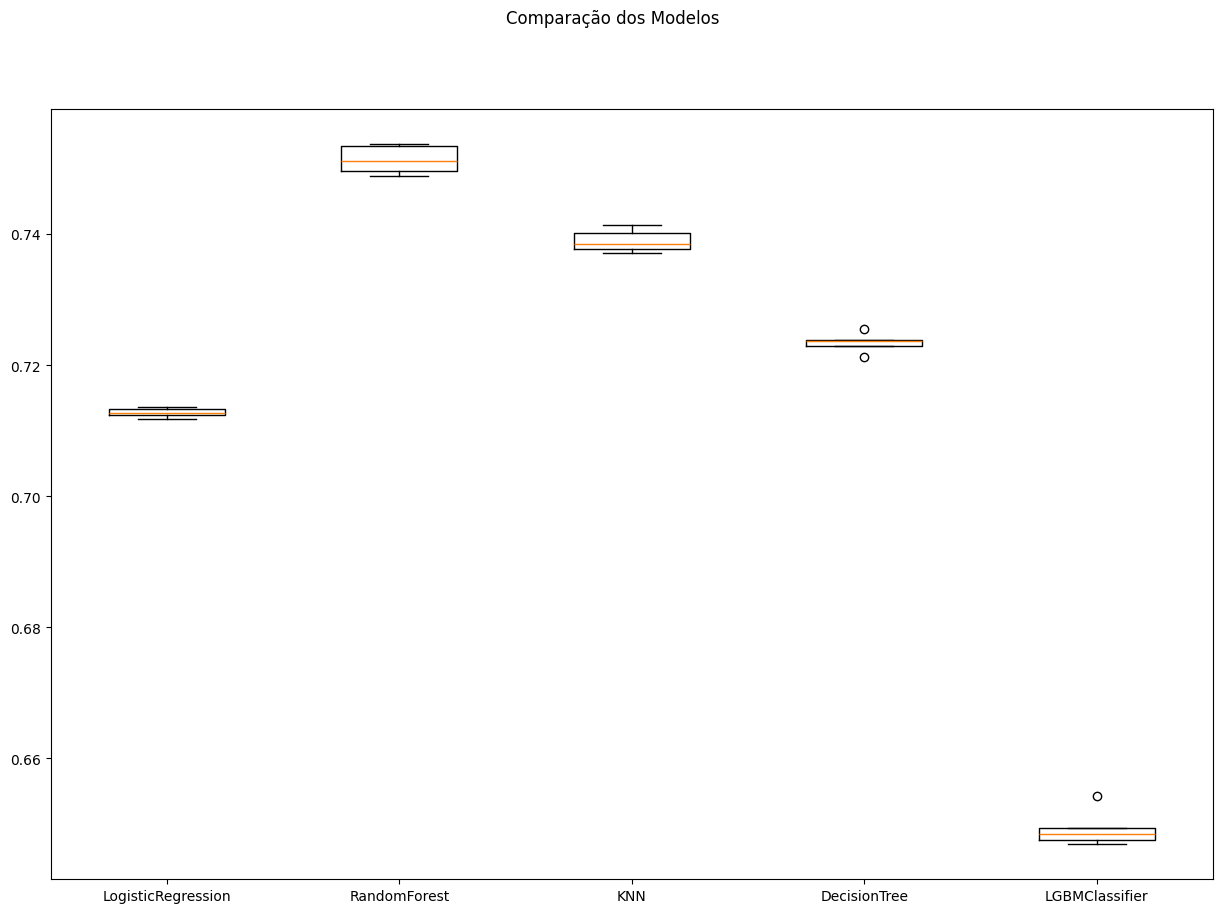

In [11]:
results = []
names = []

# Avaliação dos modelos
for name,model in candidates.items():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scoring = "f1_weighted"
    scores = cross_val_score(
            estimator=model,
            X=X, y=y,
            scoring="f1_weighted",
            cv=cv,
            n_jobs=-1
              )
    results.append(scores)
    names.append(name)
    msg = "%s: %f (%f)" % (name, scores.mean(), scores.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

🔍 **Observações:**:

*   **Ranking por desempenho médio:** RandomForest lidera o grupo com média de 0.7403, seguida por KNN (0.7390), DecisionTree (0.7234), LogisticRegression (0.7127) e LGBMClassifier (0.6493). Isso indica melhor equilíbrio global da RandomForest na validação estratificada.

*   **Estabilidade (desvio entre parênteses):** todas as variações são pequenas, sugerindo resultados consistentes entre dobras e baixo risco de instabilidade por partição específica do dado.

*   **Trade-off desempenho vs. simplicidade:** embora LogisticRegression tenha média menor, oferece interpretabilidade, rapidez e facilidade de implantação; pode ser a escolha quando latência e transparência são críticas e o ganho da RandomForest não justificar a complexidade adicional.

*   **KNN e NaiveBayes próximos:** ambos ficam relativamente perto da RandomForest, mas tendem a ter limitações conhecidas (KNN sensível à escala e custo de predição; NB com suposições fortes), o que pode afetar produção dependendo do caso de uso.

*   **Árvores simples abaixo da floresta:** DecisionTree ficou por último, sinalizando overfitting e menor generalização isoladamente; reforça a vantagem do ensemble (RandomForest) sobre uma única árvore.

*   **Próximo passo prático:** afinar hiperparâmetros da RandomForest (profundidade, folhas, n_estimators, class_weight).

### 7.2 Otimização de Hiperparâmetros

A otimização de hiperparâmetros é o processo de escolher os valores de controle do modelo que maximizam uma métrica de validação com o objetivo de melhor o modelo.

O processo realiza uma busca exaustiva em uma grade de valores pré-definidos para os hiperparâmetros, testando todas as combinações possíveis e avaliando cada uma por validação cruzada, o que melhora a estimativa de generalização.

A validação cruzada em múltiplos folds reduz a variância da avaliação e ajuda a comparar combinações de forma justa, porém aumenta o custo total porque multiplica o número de treinamentos por combinação.

Como o custo cresce com o tamanho da grade, número de hiperparâmetros e quantidade de folds, a busca pode se tornar computacionalmente cara; em cenários extensos, alternativas como busca aleatória ou métodos bayesianos costumam ser mais eficientes.

⚠️ **Atenção:** o tempo de processamento da otimização, com a grade inicial de hiperparâmetros e número de *folds* definidos, mostrou-se inviável para o *runtime* no Google Colab. Esse grid completo (representado no código por "param_grid_full") foi executado na máquina local do aluno, com os seguintes resulktados:

**Tempo de processamento ⏱️:** 23188.207 segundos (aproximadamente 6h30min)

**Melhores hiperparâmetros:** {'model__bootstrap': True, 'model__class_weight': 'balanced', 'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

**Melhor ROC AUC (CV):** 0.7127346935622612

Para efeito de evidenciamento da aplicação da técnica de otimização, foi utilizado uma grade de de valores simplificada ("param_grid_reduzido"), sendo possível verificar sua execução no Google Colab.

In [12]:
rf_pipe = candidates['RandomForest']

# Grid de hiperparâmetros
param_grid_full = {
    "model__n_estimators": [300, 600, 900],
    "model__max_depth": [6, 8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__bootstrap": [True],
    "model__class_weight": ["balanced", "balanced_subsample"]
}

param_grid_reduzido = {
    "model__n_estimators": [300],#
    "model__max_depth": [6],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt"],#
    "model__class_weight": ["balanced"]#
}

#param_grid = param_grid_full
param_grid = param_grid_reduzido
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {
    "f1_weighted": make_scorer(f1_score, average="weighted"),
    "roc_auc": "roc_auc"
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_weighted",
    cv=cv,
    n_jobs=2,
    pre_dispatch="2*n_jobs",
    verbose=2
)

print("Iniciando o processamento do Grid 🏃🏻💨...")

t0 = time.time()
grid.fit(X_train, y_train)
t1 = time.time()
print(f"Tempo de processamento ⏱️: {round(t1 - t0, 3)}\n")

print("Melhores hiperparâmetros:", grid.best_params_)
cvres = pd.DataFrame(grid.cv_results_)
print("Melhor ROC AUC (CV):", cvres["mean_test_roc_auc"].max())

Iniciando o processamento do Grid 🏃🏻💨...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Tempo de processamento ⏱️: 194.047

Melhores hiperparâmetros: {'model__class_weight': 'balanced', 'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Melhor ROC AUC (CV): 0.7127346935622612


In [13]:
#Atribuindo o modelo com os melhores hiperparâmetros
best_model = Pipeline([
    ("pre", preprocess),
    ("model", RandomForestClassifier(
        random_state=SEED,
        class_weight="balanced",
        max_depth=6,
        max_features="sqrt",
        min_samples_leaf=1,
        n_estimators=300,
        n_jobs=-1
    ))
])


## 8. Avaliação final, análise de erros e limitações
- **Compare** baseline vs melhor modelo.  
- Faça **análise de erros** (ex.: matriz de confusão, casos pior previstos, resíduos).  
- Discuta **limitações**: dados, métricas, viés, generalização.


Processando o baseline 🕐...
Finalizado o processamento 🏁. Tempo (s): 0.526
              precision    recall  f1-score   support

          No       0.80      1.00      0.89     17642
         Yes       0.00      0.00      0.00      4464

    accuracy                           0.80     22106
   macro avg       0.40      0.50      0.44     22106
weighted avg       0.64      0.80      0.71     22106



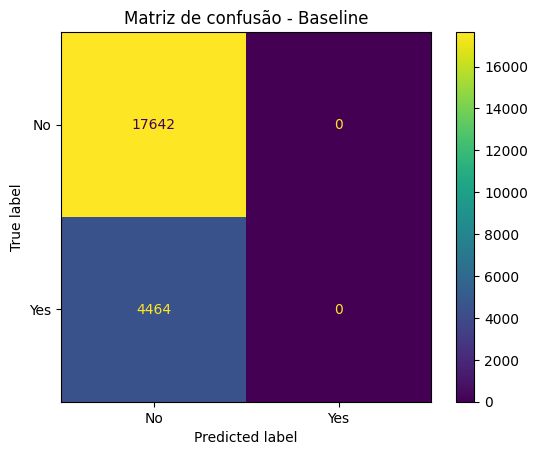

In [14]:
#Processamento da baseline
print("Processando o baseline 🕐...")
t0 = time.time()
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
t1 = time.time()
print("Finalizado o processamento 🏁. Tempo (s):",round(t1 - t0, 3))
print(classification_report(y_test, y_pred))
try:
    ConfusionMatrixDisplay.from_estimator(baseline, X_test, y_test)
    plt.title("Matriz de confusão - Baseline")
    plt.show()
except Exception as e:
    print("Não foi possível plotar a matriz de confusão:", e)


Processando o melhor modelo encontrado 🕐...
Finalizado o processamento 🏁. Tempo (s): 23.239
              precision    recall  f1-score   support

          No       0.93      0.49      0.64     17642
         Yes       0.30      0.86      0.44      4464

    accuracy                           0.56     22106
   macro avg       0.62      0.67      0.54     22106
weighted avg       0.80      0.56      0.60     22106



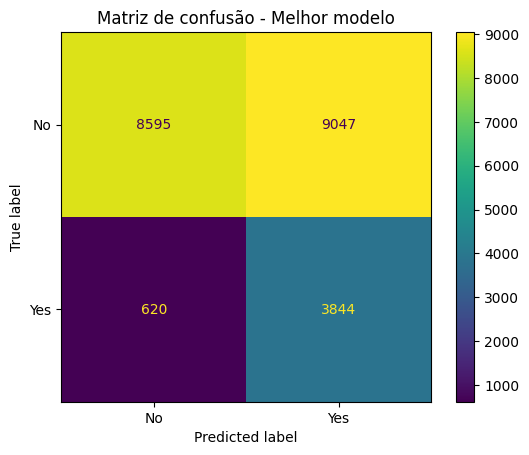

In [15]:
#Processamento do melhor modelo
print("Processando o melhor modelo encontrado 🕐...")
t0 = time.time()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
t1 = time.time()
print("Finalizado o processamento 🏁. Tempo (s):",round(t1 - t0, 3))
print(classification_report(y_test, y_pred))
try:
    ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
    plt.title("Matriz de confusão - Melhor modelo")
    plt.show()
except Exception as e:
    print("Não foi possível plotar a matriz de confusão:", e)

## 🧠 Avaliação dos resultados obtidos com o modelo:

O modelo está altamente sensível para detectar ausências (“Yes”), mas à custa de muitos alarmes falsos em consultas que ocorreriam (“No”). Em termos práticos, captura a maioria dos faltosos (recall 0.86 em “Yes”), porém erra bastante quando diz que alguém vai faltar (precision 0.30), o que pode sobrecarregar intervenções preventivas e desgastar a experiência do paciente.

**Comparação entre baseline e o melhor modelo candidato:**

*  Comparando com um DummyClassifier “most_frequent”, o melhor modelo candidato supera trivialmente em recall de “Yes”, pois o dummy nunca prevê ausências e, portanto, tem recall 0 para “Yes”, enquanto o modelo alcança recall 0.86 para “Yes”, embora com queda acentuada de precisão para essa classe;

*  Comportamento do Dummy “most_frequent”: prevê sempre “No”, resultando em precisão e recall perfeitos para “No” apenas se todas as previsões forem “No”, mas recall 0 e F1 0 para “Yes”, o que torna o macro F1 muito baixo e inutilizável para identificar faltas;

*  O melhor modelo candidato mantém precisão alta em “No” (0.93) com recall 0.49, porém muda o ponto de operação para capturar ausências com recall 0.86 em “Yes” e F1 0.44, aceitando muitos falsos positivos; isso é preferível a um baseline que não detecta nenhuma falta;

*  Acurácia: o Dummy pode apresentar acurácia alta uma vez que a base é desbalanceada a favor de “No”, mas essa métrica mascara o fracasso total em “Yes”; no melhor modelo candidato, a acurácia 0.56 não conta toda a história, e o ganho real está no recall de “Yes” e no macro F1 superior ao dummy;

*  Implicação operacional: o Dummy não permite qualquer intervenção preventiva, já que não sinaliza faltas; o melhor modelo candidato cria um ponto de partida acionável, que pode ser refinado via ajuste de limiar para elevar a precisão de “Yes” sem perder demasiadamente o recall.

**Detalhamento por classe:**

*  Classe “No” (presença): alta precisão 0.93 significa que, quando prevê presença, costuma acertar; porém recall 0.49 indica que quase metade dos presentes foi rotulada como “Yes” em algum momento, refletindo viés do limiar para marcar ausências;
*  Classe “Yes” (absenteísmo): recall 0.87 é excelente para capturar faltas, mas a precisão 0.30 é baixa, sugerindo muitos falsos positivos; o F1 de 0.44 mostra que o equilíbrio ainda está bem desfavorável.

**Comentário sobre as métricas gerais:**

Acurácia 0.56 é pouco informativa num cenário desbalanceado; macro F1 0.54 revela desempenho mediano quando se dá igual peso às classes, e o weighted F1 0.60 é puxado pelo tamanho da classe “No”, mascarando a baixa precisão de “Yes”.



## 9. Conclusão
Este estudo abordou a predição de absenteísmo em consultas médicas sob um cenário desbalanceado, estruturando todo o fluxo com pipelines reprodutíveis, validação cruzada estratificada e comparação sistemática de modelos e estratégias. Em termos de desempenho, a RandomForest se destacou como ponto de partida robusto, apresentando os melhores resultados médios em F1 ponderado com AUC competitiva, além de boa estabilidade entre dobras. A análise de matrizes de confusão mostrou o trade-off crítico do problema: elevar o recall para “Yes” (faltas) ao custo de precisão mais baixa e maior volume de falsos positivos.

**Resultados-chave:**

*  Validação cruzada indicou superioridade consistente da RandomForest em F1 ponderado, com variação baixa entre dobras e AUC semelhante à de alternativas bem estabelecidas;

*  As matrizes de confusão evidenciaram que o ganho real está em capturar faltas (alto recall de “Yes”), mas com perda de precisão que pode onerar intervenções; acurácia bruta se mostrou pouco informativa no desbalanceamento, tornando macro-F1 e F1 ponderado métricas mais alinhadas ao objetivo;

*  Buscas exaustivas de hiperparâmetros em runtime restrito mostraram custo elevado; Para contornar essa restrição, o algoritmo foi executado em másquina local com maior poder de processamento, com o devido o evidenciamento da técnica utilizada.

**Principais trade-offs:**

*  Desempenho vs. custo operacional: aumentar recall de “Yes” melhora cobertura de faltas, mas gera alarmes falsos; o ponto ótimo depende do custo relativo de falso positivo vs. falso negativo e deve ser escolhido via ajuste de threshold em curvas Precision-Recall.

*  Complexidade vs. interpretabilidade: RandomForest tendeu a superar modelos lineares em F1 ponderado; porém, Regressão Logística e SVM calibrado podem ser preferíveis quando explicabilidade e governança são exigidas, desde que o desempenho atenda os critérios do negócio.

*  Precisão global vs. justiça entre classes: métricas agregadas ponderadas favorecem a classe majoritária; macro-F1 e métricas por classe devem orientar a operação para não invisibilizar a minoria (faltas).

**Melhorias futuras:**

*  Features: um trabalho estruturado de engenharia de features pode identificar quais atributos realmente contribuem para a predição e, ao mesmo tempo, revelar lacunas informacionais que limitam o desempenho;

*  Modelos: testar gradient boosting moderno (XGBoost/LightGBM/CatBoost) com regularização e monotonic constraints quando aplicável; explorar métodos sensíveis a custo e focal loss; considerar SVM RBF com calibração, e ensembles heterogêneos para robustez;

*  Tuning: substituir grades grandes por estratégias eficientes (random search com distribuições informadas, halving, otimização bayesiana);

*  Rebalanceamento e decisão: comparar reponderação (class_weight) com SMOTE/undersampling dentro de pipelines reprodutíveis;

**Conclusão**

O projeto demonstrou, com evidências empíricas, que há ganho substancial sobre baselines triviais, sobretudo na detecção de faltas, ao custo de precisão que deve ser controlado por limiar e desenho de ação. A RandomForest surge como escolha pragmática inicial, mas o avanço esperado reside em melhores dados e features, métodos de busca mais eficientes e calibragem criteriosa de probabilidades e thresholds. Com essa abordagem, a expectativa é elevar F1 por classe, reduzir falsos positivos operacionais e, principalmente, alinhar o ponto de operação ao custo real do negócio, tornando o sistema efetivo para reduzir o absenteísmo com eficiência.

A análise exploratória sugere que as variáveis disponíveis não oferecem sinal preditivo suficiente para o problema de absenteísmo, uma vez que a matriz de correlação indica relações fracas ou inexistentes entre as features e o alvo, o que limita o poder discriminativo dos modelos lineares e não lineares.

Em contextos assim, correlação baixa com o alvo tende a reduzir o teto de desempenho, exigindo enriquecimento de dados e engenharia de atributos para capturar relações não lineares e interações que a correlação, focada em dependência linear, não revela adequadamente.

O trabalho atingiu os objetivos acadêmicos propostos ao conduzir, de ponta a ponta, um processo completo de aprendizado de máquina: desde a exploração e preparação dos dados, passando pela construção de pipelines reprodutíveis, definição de métricas apropriadas para dados desbalanceados, validação cruzada estratificada, comparação de modelos e ajuste de hiperparâmetros, até a análise crítica de matrizes de confusão.